# **Pre-entrega 6: Orquestador Multi-Agente**

## **Instalación de dependencias**

In [ ]:
!pip install -q -U \
langchain \
langchain-classic \
langchain-core \
langchain-community \
langchain-text-splitters \
langchain-google-genai \
langgraph \
pinecone \
langchain-pinecone \
langchain-huggingface \
sentence-transformers \
rank_bm25 \
pydantic \
python-dotenv \
tiktoken


print("\n" + "=" * 70)
print("⚠️  REINICIÁ EL ENTORNO DE EJECUCIÓN AHORA y seguí desde la próxima")
print("    celda, SIN volver a correr esta celda de instalación.")
print("=" * 70)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.7/163.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.0/572.0 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.6/587.6 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.3/259.3 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6

In [ ]:
!pip install -q --force-reinstall "numpy<2.3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 38.4 MB/s eta 0:00:00


## **API keys**

In [ ]:
import os
from getpass import getpass

if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass("🔑 GOOGLE_API_KEY: ").strip()

if not os.environ.get("PINECONE_API_KEY"):
    os.environ["PINECONE_API_KEY"] = getpass("🔑 PINECONE_API_KEY: ").strip()

🔑 GOOGLE_API_KEY: ··········
🔑 PINECONE_API_KEY: ··········


**Reconectar al sistema RAG de la Pre-entrega 4**

Reconstruimos el mismo RAGSystem (BM25 + Pinecone) — si el índice techcorp-rag-hibrido ya existe con los vectores cargados, no se reingesta nada, solo se conecta.

In [ ]:
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_pinecone import PineconeVectorStore
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from pinecone import Pinecone, ServerlessSpec
from typing import List, Dict

# --- Documentos (mismos que en la Pre-entrega 3/4) ---
os.makedirs("data", exist_ok=True)
documentos = {
    "politica_vacaciones.txt": "Política de Vacaciones - TechCorp\n\nLos empleados con menos de 5 años de antigüedad acceden a 14 días corridos de vacaciones. Los empleados con 5 a 10 años acceden a 21 días. Los empleados con más de 10 años acceden a 28 días.",
    "politica_teletrabajo.txt": "Política de Teletrabajo - TechCorp\n\nEl esquema estándar es de 3 días de trabajo remoto y 2 días presenciales por semana. Soporte Técnico Nivel 1 y Recepción son 100% presenciales.",
    "politica_seguridad_informatica.txt": "Política de Seguridad Informática - TechCorp\n\nLas contraseñas deben renovarse cada 90 días y usar 2FA obligatorio en todos los sistemas internos.",
    "onboarding_nuevos_empleados.txt": "Proceso de Onboarding - TechCorp\n\nEl proceso dura 4 semanas: inducción general, capacitación del rol, y cierre con Recursos Humanos.",
}
for nombre, contenido in documentos.items():
    with open(f"data/{nombre}", "w", encoding="utf-8") as f:
        f.write(contenido)

loader = DirectoryLoader("data", glob="*.txt", loader_cls=TextLoader, loader_kwargs={"encoding": "utf-8"})
chunks = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=600, chunk_overlap=100).split_documents(loader.load())
for i, c in enumerate(chunks):
    c.metadata["source"] = os.path.basename(c.metadata["source"])
    c.metadata["chunk_id"] = i

# --- Embeddings + Pinecone (conectar, no recrear) ---
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
INDEX_NAME = "techcorp-rag-hibrido"
NAMESPACE = "politicas-internas"

pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])
if INDEX_NAME not in [i["name"] for i in pc.list_indexes()]:
    pc.create_index(name=INDEX_NAME, dimension=384, metric="cosine",
                     spec=ServerlessSpec(cloud="aws", region="us-east-1"))

vectorstore = PineconeVectorStore(index_name=INDEX_NAME, embedding=embeddings, namespace=NAMESPACE)

if pc.Index(INDEX_NAME).describe_index_stats()["namespaces"].get(NAMESPACE, {}).get("vector_count", 0) == 0:
    print("🆕 Namespace vacío — ingestando chunks...")
    vectorstore.add_documents(chunks)
else:
    print("♻️ Namespace ya tiene datos — no se reingesta")

# --- Retriever híbrido ---
retriever_bm25 = BM25Retriever.from_documents(chunks)
retriever_bm25.k = 5
retriever_vectorial = vectorstore.as_retriever(search_kwargs={"k": 5, "namespace": NAMESPACE})
retriever_hibrido = EnsembleRetriever(retrievers=[retriever_bm25, retriever_vectorial], weights=[0.5, 0.5])


class RAGSystem:
    def __init__(self, retriever, k: int = 5):
        self.retriever = retriever
        self.k = k

    def obtener_top_k(self, query: str) -> List[Dict]:
        docs = self.retriever.invoke(query)[: self.k]
        return [{"contenido": d.page_content, "fuente": d.metadata.get("source", "?")} for d in docs]


rag_system = RAGSystem(retriever_hibrido)
print("✅ RAGSystem reconectado")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

♻️ Namespace ya tiene datos — no se reingesta
✅ RAGSystem reconectado


## **state.py: el estado compartido**

Evita la "pérdida de contexto en la comunicación asíncrona" que menciona la consigna. El campo contribuciones usa Annotated[..., operator.add] como reducer — cada nodo que devuelve una nueva contribución la suma a la lista existente en vez de pisarla, así queda un registro completo de quién aportó qué.

In [ ]:
import operator
from typing import Annotated, Optional, List, Dict
from langgraph.graph import MessagesState


class AgentState(MessagesState):
    """Hereda 'messages' (con su propio reducer add_messages) y suma campos propios."""
    next_agent: Optional[str]
    contribuciones: Annotated[List[Dict[str, str]], operator.add]
    pasos: int
    task_completed: bool

## **Herramienta del Investigador**

In [ ]:
from langchain_core.tools import tool


@tool
def buscar_en_politicas_internas(pregunta: str) -> str:
    """Busca información en las políticas internas de TechCorp (vacaciones, teletrabajo,
    seguridad informática, onboarding). Usar para cualquier pregunta sobre reglas o
    números concretos de la empresa."""
    resultados = rag_system.obtener_top_k(pregunta)
    if not resultados:
        return "No se encontró información relevante en las políticas."
    return "\n\n".join(f"[Fuente: {r['fuente']}] {r['contenido']}" for r in resultados)

## **Herramienta del Analista (calculadora segura)**

usar eval() a secas sobre texto generado por un LLM es una puerta abierta a ejecución de código arbitrario. Acá parseamos la expresión con ast y solo permitimos operaciones aritméticas — nada de imports, funciones ni acceso a builtins.

In [ ]:
import ast
import operator as op

_OPERADORES = {
    ast.Add: op.add, ast.Sub: op.sub, ast.Mult: op.mul,
    ast.Div: op.truediv, ast.Pow: op.pow, ast.USub: op.neg,
}


def _evaluar_nodo(nodo):
    if isinstance(nodo, ast.Constant):
        return nodo.value
    if isinstance(nodo, ast.BinOp):
        return _OPERADORES[type(nodo.op)](_evaluar_nodo(nodo.left), _evaluar_nodo(nodo.right))
    if isinstance(nodo, ast.UnaryOp):
        return _OPERADORES[type(nodo.op)](_evaluar_nodo(nodo.operand))
    raise ValueError("Expresión no permitida")


@tool
def calculadora(expresion: str) -> str:
    """Evalúa una expresión matemática (+, -, *, /, **, paréntesis). Ejemplo: '5*14 + 5*21 + 2*28'."""
    try:
        resultado = _evaluar_nodo(ast.parse(expresion, mode="eval").body)
        return f"Resultado: {resultado}"
    except Exception as e:
        return f"Error al calcular '{expresion}': {e}"

## **Los dos agentes especialistas**

In [ ]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash", temperature=0)

agente_investigador = create_agent(
    model=llm,
    tools=[buscar_en_politicas_internas],
    system_prompt=(
        "Sos un agente de investigación. Tu única función es buscar datos concretos en "
        "las políticas internas de TechCorp usando tu herramienta. NO hagas cálculos. "
        "Respondé de forma breve con los datos encontrados y su fuente."
    ),
)

agente_analista = create_agent(
    model=llm,
    tools=[calculadora],
    system_prompt=(
        "Sos un agente de análisis matemático. Tu única función es calcular usando tu "
        "herramienta a partir de los números que te den. NO busques información nueva."
    ),
)

## **Nodos que envuelven a los agentes (con contexto acotado)**

Evita la "Contaminación de Contexto". Cada nodo le pasa al especialista solo el último mensaje (la instrucción puntual), no toda la conversación acumulada — así el especialista no se confunde con metadata que no le corresponde.

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage


def nodo_investigador(state: AgentState) -> dict:
    tarea = state["messages"][-1].content  # contexto acotado, no todo el historial
    resultado = agente_investigador.invoke({"messages": [HumanMessage(content=tarea)]})
    respuesta = resultado["messages"][-1].content

    return {
        "messages": [AIMessage(content=respuesta, name="investigador")],
        "contribuciones": [{"agente": "investigador", "aporte": respuesta}],
        "pasos": state.get("pasos", 0) + 1,
    }


def nodo_analista(state: AgentState) -> dict:
    tarea = state["messages"][-1].content
    resultado = agente_analista.invoke({"messages": [HumanMessage(content=tarea)]})
    respuesta = resultado["messages"][-1].content

    return {
        "messages": [AIMessage(content=respuesta, name="analista")],
        "contribuciones": [{"agente": "analista", "aporte": respuesta}],
        "pasos": state.get("pasos", 0) + 1,
    }

## **El Supervisor (router inteligente)**

El MAX_PASOS corta el flujo aunque el LLM insista en seguir delegando.

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal

MAX_PASOS = 6


class DecisionSupervisor(BaseModel):
    next: Literal["investigador", "analista", "FINISH"] = Field(
        description="Próximo agente a invocar, o FINISH si la tarea ya está completa"
    )
    razon: str = Field(description="Breve justificación de la decisión")


SUPERVISOR_PROMPT = """Sos el Supervisor de un equipo con dos especialistas:
- investigador: busca datos concretos en las políticas internas de TechCorp.
- analista: hace cálculos matemáticos a partir de datos ya obtenidos.

Reglas:
1. Si falta un dato de la empresa, mandá a 'investigador'.
2. Si ya se buscó el dato pero falta calcular, mandá a 'analista'.
3. Si ya se buscó Y se calculó lo necesario, respondé 'FINISH'.
4. Nunca repitas el mismo agente dos veces seguidas si ya cumplió su parte.

Contribuciones hasta ahora:
{contribuciones}
"""

llm_supervisor = llm.with_structured_output(DecisionSupervisor)


def nodo_supervisor(state: AgentState) -> dict:
    if state.get("pasos", 0) >= MAX_PASOS:
        return {"next_agent": "FINISH", "task_completed": True}

    contribuciones_texto = "\n".join(
        f"- {c['agente']}: {c['aporte'][:200]}" for c in state.get("contribuciones", [])
    ) or "(ninguna todavía)"

    pregunta_original = state["messages"][0].content
    prompt_sistema = SUPERVISOR_PROMPT.format(contribuciones=contribuciones_texto)

    decision = llm_supervisor.invoke([
        {"role": "system", "content": prompt_sistema},
        {"role": "user", "content": f"Tarea original: {pregunta_original}"},
    ])

    return {"next_agent": decision.next, "task_completed": decision.next == "FINISH"}

## **Nodo de síntesis (respuesta final al usuario)**

In [ ]:
def nodo_sintesis(state: AgentState) -> dict:
    contribuciones_texto = "\n".join(f"- [{c['agente']}] {c['aporte']}" for c in state.get("contribuciones", []))
    pregunta_original = state["messages"][0].content

    prompt = (
        f"Pregunta original: {pregunta_original}\n\nAportes del equipo:\n{contribuciones_texto}\n\n"
        "Redactá una respuesta final clara y breve combinando estos aportes."
    )
    respuesta_final = llm.invoke(prompt)

    return {"messages": [AIMessage(content=respuesta_final.content, name="supervisor")]}

## **Construcción del grafo**

In [ ]:
from langgraph.graph import StateGraph, START, END


def enrutar(state: AgentState) -> Literal["investigador", "analista", "sintesis"]:
    if state["next_agent"] == "FINISH":
        return "sintesis"
    return state["next_agent"]


grafo = StateGraph(AgentState)
grafo.add_node("supervisor", nodo_supervisor)
grafo.add_node("investigador", nodo_investigador)
grafo.add_node("analista", nodo_analista)
grafo.add_node("sintesis", nodo_sintesis)

grafo.add_edge(START, "supervisor")
grafo.add_conditional_edges("supervisor", enrutar, {
    "investigador": "investigador",
    "analista": "analista",
    "sintesis": "sintesis",
})
grafo.add_edge("investigador", "supervisor")
grafo.add_edge("analista", "supervisor")
grafo.add_edge("sintesis", END)

app = grafo.compile()

## **Visualización del grafo**

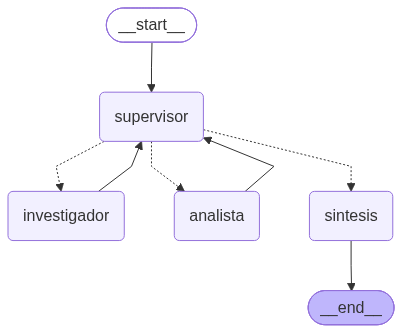

In [ ]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## **Prueba: pregunta que requiere los DOS dominios**

In [ ]:
from langchain_core.messages import HumanMessage

pregunta = (
    "Un empleado va a cumplir 12 años en TechCorp. Tuvo 14 días de vacaciones los primeros "
    "5 años, 21 los siguientes 5, y ahora tiene derecho a 28. ¿Cuántos días de vacaciones "
    "acumuló en total en esos 12 años?"
)

estado_inicial = {
    "messages": [HumanMessage(content=pregunta)],
    "next_agent": None,
    "contribuciones": [],
    "pasos": 0,
    "task_completed": False,
}

print("🎬 Flujo de delegación:\n")
for evento in app.stream(estado_inicial, stream_mode="updates"):
    for nodo, actualizacion in evento.items():
        print(f"🔹 Nodo: {nodo}")
        if "messages" in actualizacion:
            for m in actualizacion["messages"]:
                print(f"   [{getattr(m, 'name', 'sistema')}] {m.content[:250]}")
        print()

🎬 Flujo de delegación:

🔹 Nodo: supervisor

🔹 Nodo: analista
   [analista] [{'type': 'text', 'text': 'El empleado acumuló un total de **231 días** de vacaciones en esos 12 años. \n\nEl cálculo realizado es el siguiente:\n* Primeros 5 años: $5 \\times 14 = 70$ días\n* Siguientes 5 años: $5 \\times 21 = 105$ días\n* Últimos 2 años (para completar los 12): $2 \\times 28 = 56$ días\n\nTotal: $70 + 105 + 56 = 231$ días.', 'extras': {'signature': 'EroBCrcBAWkUfRNJB5p/qXdMKk1yt45vJABBUysZNkfBAjhZ61B5mnTLJH97WqyaHeYlzDuDXaaTWtyoCc4IsPZWBlAqXgJFWU+9cttB3KYmWU/69cAO5/i5Uw6TbqxRTTDzM1vuy13ap5OOaQaC/kiOfrrnXww+5p4V+muLZkA74AbAH1WNVTM3Ql6Uo3PQPsRFMQDAkoBdRPES9KGgicFNj24UUsNC0dK7LHl8G76wn7EYhQqjPU26JSIA'}}]

🔹 Nodo: supervisor

🔹 Nodo: sintesis
   [supervisor] [{'type': 'text', 'text': 'El empleado acumuló un total de **231 días** de vacaciones a lo largo de sus 12 años en la empresa. \n\nEl cálculo detallado es el siguiente:\n\n* **Primeros 5 años:** 5 años × 14 días = 70 días\n* **Siguientes 5 año

## **Respuesta final**

In [ ]:
resultado_final = app.invoke(estado_inicial)
print("RESPUESTA FINAL:\n")
print(resultado_final["messages"][-1].content)

RESPUESTA FINAL:

[{'type': 'text', 'text': 'El empleado acumuló un total de **231 días de vacaciones** en sus 12 años de antigüedad. \n\nEl cálculo detallado es el siguiente:\n\n* **Primeros 5 años:** 5 años × 14 días = 70 días\n* **Siguientes 5 años:** 5 años × 21 días = 105 días\n* **Últimos 2 años:** 2 años × 28 días = 56 días\n\n**Total:** 70 + 105 + 56 = **231 días**.', 'extras': {'signature': 'Eq4OCqsOAWkUfRPSR5xIinwzN9wcMTj8NjcSnK8o3kXmT0n2/QxusjawFjTSMtjRaIZS0bAIDBocEbH8OGhOD+ga7EPPIDgGyDIiDjIgbrZmHo/e51hJndFsnESNiqMkbmcBCJiBAqsFoSNWCPr+6mDAgY/1320wcwb39tQJVY0lTtQWTrYEF9KLvwuoODkQG7sw2w0KvMjbbug/lkIYOfMU72Rz48SZLgDmkKCB8q97JC8DuGEaVzkbh4Ta5ux2PTFu/Dnbp/9f8dWSWooSk6QkYIOXyI6NPS9uwWmnbn7Hcrg69Ayhonz0IwJpbF8exan5mpdIJ7r0who3n8eze8kSDvjL2bZ2QV0p8nirk6TnFU5GhpQ2faWsM1G3bwVwtLd2d3jO5aJ+RAukSXPbfQC1MTrQ7eC+JpIr4o3gQqMVUlV3CUQXiICysvKaStIsMaQjOeRTsO/uf9tKaI/18sAR7Lk33PXJ7LDRYSnU+st1qL9u1mhosYAAwBsscnfJvokWViHR4fxwIVhtL81tMIOBvjsEDm7N7gSF6AsB9YZ5TzH6koywUjj2x3Iq9nG5U6xmkO918ulyEdOSuprc

Gemini devuelve el contenido a través de langchain-google-genai: en vez de un string simple, message.content puede venir como una lista de bloques ([{'type': 'text', 'text': '...', 'extras': {...}}]). El campo extras.signature es metadata interna de Google (relacionada con el thinking del modelo, para que Gemini pueda reutilizar/verificar su propio razonamiento entre llamadas) — no es parte de la respuesta que se le quiere mostrar al usuario.